<a href="https://colab.research.google.com/github/Shruti09g/training-like-data-reconstruction-classifiers/blob/main/training_like_data_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import glob
import torch
import numpy as np
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import torchvision.utils as vutils
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.preprocessing import MinMaxScaler
from torchvision.datasets import ImageFolder

In [2]:
# Define the path to your dataset (FashionMNIST loaded via torchvision)
# train_data_dir and test_data_dir are not needed for torchvision datasets

# Set device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import torchvision.datasets as datasets

# ── Experiment config ──────────────────────────────────────────────────────────
N_PER_CLASS = 1          # images per class used to train the classifier
N_CLASSES   = 10
DATASET     = "FashionMNIST"

# FashionMNIST mean / std
fashion_mean = 0.2860
fashion_std  = 0.3530
batch_size   = 100

train_transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((fashion_mean,), (fashion_std,))
])
test_transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((fashion_mean,), (fashion_std,))
])

# Load FashionMNIST
full_train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=train_transform)
test_dataset       = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

# ── Select exactly N_PER_CLASS images per class ────────────────────────────────
targets = full_train_dataset.targets
selected_indices = []
seen_classes = {}

for idx, label in enumerate(targets):
    lbl = label.item()
    seen_classes.setdefault(lbl, 0)
    if seen_classes[lbl] < N_PER_CLASS:
        selected_indices.append(idx)
        seen_classes[lbl] += 1
    if all(v >= N_PER_CLASS for v in seen_classes.values()) and len(seen_classes) == N_CLASSES:
        break

train_dataset = torch.utils.data.Subset(full_train_dataset, selected_indices)

# FashionMNIST class names for display
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]


In [4]:
print("Training Dataset:")
print(f"  Size: {len(train_dataset)}")
print(f"  Shape: {next(iter(train_loader))[0].shape}")
print(f"  Batch Size: {train_loader.batch_size}")

print("\nTesting Dataset:")
print(f"  Size: {len(test_dataset)}")
print(f"  Shape: {next(iter(test_loader))[0].shape}")
print(f"  Batch Size: {test_loader.batch_size}")

Training Dataset:
  Size: 10
  Shape: torch.Size([10, 1, 28, 28])
  Batch Size: 100

Testing Dataset:
  Size: 10000
  Shape: torch.Size([100, 1, 28, 28])
  Batch Size: 100


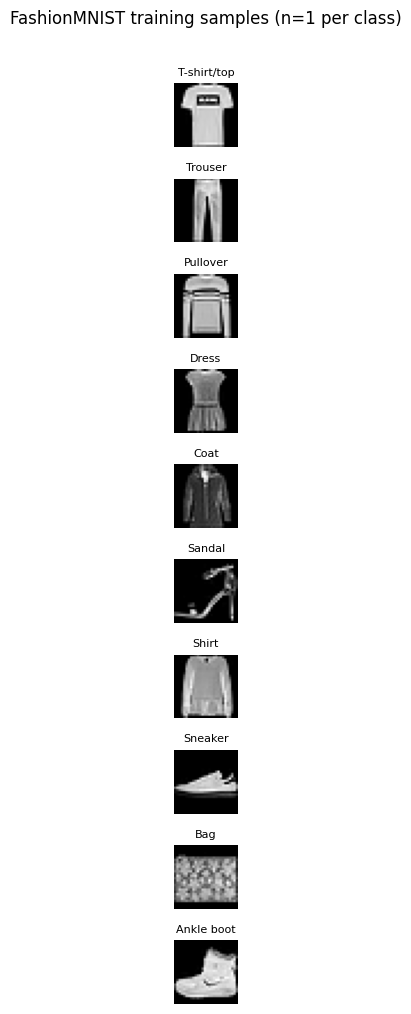

In [5]:
# Dictionary to store 1 image per class (n=1)
class_images  = {i: [] for i in range(N_CLASSES)}
class_labels  = {i: [] for i in range(N_CLASSES)}

for img, label in train_dataset:
    lbl = label if isinstance(label, int) else label.item()
    if len(class_images[lbl]) < N_PER_CLASS:
        class_images[lbl].append(img.squeeze().numpy())
    if all(len(class_images[i]) >= N_PER_CLASS for i in range(N_CLASSES)):
        break

# Plot 10 × N_PER_CLASS grid (original training samples)
fig, axs = plt.subplots(N_CLASSES, N_PER_CLASS, figsize=(3 * N_PER_CLASS, 10))
if N_PER_CLASS == 1:
    axs = axs[:, None]          # ensure 2-D indexing

for i in range(N_CLASSES):
    for j in range(N_PER_CLASS):
        axs[i][j].imshow(class_images[i][j], cmap="gray")
        axs[i][j].axis("off")
        if j == 0:
            axs[i][j].set_title(CLASS_NAMES[i], fontsize=8)

plt.suptitle(f"FashionMNIST training samples (n={N_PER_CLASS} per class)", y=1.01)
plt.tight_layout()
plt.show()


In [6]:
class Classifier(nn.Module):
    def __init__(self, nc, ncf):
        super(Classifier, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ncf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf, ncf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf * 2, ncf * 4, 3, 1, 0, bias=False),
            nn.Flatten(),
            nn.Linear(ncf * 100, ncf * 2),
            nn.ReLU(),

            nn.Linear(ncf * 2, 10)
        )

    def forward(self, input):
        return self.main(input)

In [7]:
import torch
import torch.nn as nn
from torchsummary import summary
from einops.layers.torch import Rearrange
from einops import rearrange, repeat
from torch.nn import functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- CNN Classifier ---
class CNNClassifier(nn.Module):
    def __init__(self, nc=1, ncf=64):
        super(CNNClassifier, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ncf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf, ncf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf * 2, ncf * 4, 3, 1, 0, bias=False),
            nn.Flatten(),
            nn.Linear(ncf * 100, ncf * 2),
            nn.ReLU(),

            nn.Linear(ncf * 2, 10)
        )

    def forward(self, input):
        return self.main(input)

# --- MLP Classifier ---
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128):
        super(MLPClassifier, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim * 2, hidden_dim * 4),
            nn.BatchNorm1d(hidden_dim * 4),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim * 4, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.main(x)

# --- Vision Transformer ---
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 4, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        b, n, _, h = *x.shape, self.heads
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = h), qkv)

        dots = torch.einsum('b h i d, b h j d -> b h i j', q, k) * self.scale
        attn = self.attend(dots)

        out = torch.einsum('b h i j, b h j d -> b h i d', attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout))
            ]))
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class ViT(nn.Module):
    def __init__(self, *, image_size=28, patch_size=4, num_classes=10, dim=64, depth=2, heads=4, mlp_dim=64, channels=1, dim_head=64, dropout=0., emb_dropout=0., pool='cls'):
        super().__init__()
        assert image_size % patch_size == 0, "Image must be divisible by patch size"
        num_patches = (image_size // patch_size) ** 2
        patch_dim = channels * patch_size * patch_size

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape
        cls_tokens = repeat(self.cls_token, '() n d -> b n d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :x.size(1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x[:, 0] if self.pool == 'cls' else x.mean(dim=1)
        x = self.to_latent(x)
        return self.mlp_head(x)


In [8]:

# Instantiate models
cnn_model = CNNClassifier(nc=1, ncf=32).to(device)
mlp_model = MLPClassifier(input_dim=28*28, hidden_dim=128).to(device)
vit_model = ViT(image_size=28, patch_size=4, num_classes=10, channels=1, dim=64, depth=2, heads=4, mlp_dim=64).to(device)

# Print model summaries
print("=== CNN ===")
summary(cnn_model, (1, 28, 28))
print("\n=== MLP ===")
summary(mlp_model, (1, 28, 28))
print("\n=== ViT ===")
summary(vit_model, (1, 28, 28))


=== CNN ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             512
       BatchNorm2d-2           [-1, 32, 14, 14]              64
         LeakyReLU-3           [-1, 32, 14, 14]               0
            Conv2d-4             [-1, 64, 7, 7]          32,768
       BatchNorm2d-5             [-1, 64, 7, 7]             128
         LeakyReLU-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 5, 5]          73,728
           Flatten-8                 [-1, 3200]               0
            Linear-9                   [-1, 64]         204,864
             ReLU-10                   [-1, 64]               0
           Linear-11                   [-1, 10]             650
Total params: 312,714
Trainable params: 312,714
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0

In [9]:
#VC Generator
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc, n_classes):
        super(Generator, self).__init__()
        # Linear layer to map the softmaxed vector to the size nz
        self.embed = nn.Linear(n_classes, nz)

        # The main model architecture remains unchanged
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz * 2, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            #nn.Dropout2d(0.2),
            nn.Dropout2d(0.3),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            #nn.Dropout2d(0.2),
            nn.Dropout2d(0.3),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 2, bias=False),
            nn.BatchNorm2d(ngf),
            #nn.Dropout2d(0.2),
            nn.Dropout2d(0.3),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, class_vector):
        # Map the class vector to the latent space size
        embed_vector = self.embed(class_vector).unsqueeze(-1).unsqueeze(-1)
        # Concatenate with the latent vector z
        input = torch.cat([z, embed_vector], 1)
        return self.main(input)

In [10]:
#VMC Generator
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc=1, n_classes=10):  # Default nc=1 for grayscale output, n_classes=10
        super(Generator, self).__init__()
        self.nz = nz
        self.n_classes = n_classes

        # Define the embedding layer for class matrix diagonal
        self.embedding = nn.Linear(n_classes, nz)

        # Adjust layers before concatenation to take nz*2 channels
        self.layers_before_concat = nn.Sequential(
            nn.ConvTranspose2d(nz * 2, ngf, 4, 1, 0),  # Adjusted input channels to nz*2
            nn.BatchNorm2d(ngf),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf * 2, 4, 1, 0),
            nn.BatchNorm2d(ngf * 2),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf * 4, 4, 1, 0),
            nn.BatchNorm2d(ngf * 4),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),
        )

        # Layers after concatenation remain the same
        self.layers_after_concat = nn.Sequential(
            nn.ConvTranspose2d(ngf * 4 + 1, ngf * 8, 4, 1, 1),
            nn.BatchNorm2d(ngf * 8),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0),
            nn.BatchNorm2d(ngf),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 1, 1),
            nn.Tanh(),
        )

    def forward(self, latent_vector, conditioning_vector):
        # Get the argmax of the conditioning vector
        argmax_index = torch.argmax(conditioning_vector, dim=1)

        # Create a class matrix based on the argmax index
        class_matrix = torch.zeros((latent_vector.size(0), self.n_classes, self.n_classes)).to(latent_vector.device)
        for i, idx in enumerate(argmax_index):
            class_matrix[i, idx, :] = 1
            class_matrix[i, :, idx] = 1

        # Map the conditioning vector to nz dimensions
        embedding_vector = self.embedding(conditioning_vector).unsqueeze(2).unsqueeze(3)

        # Concatenate the latent vector with the conditioned input
        concat1 = torch.cat([latent_vector, embedding_vector], dim=1)

        # Pass the combined input through the layers before concatenation
        upsample1 = self.layers_before_concat(concat1)

        # Ensure class_matrix has the correct shape for concatenation
        class_matrix = class_matrix.unsqueeze(1)

        # Concatenate the upsampled noise with the class matrix
        concat2 = torch.cat([upsample1, class_matrix], dim=1)

        # Pass through the layers after concatenation to generate the output
        upsample2 = self.layers_after_concat(concat2)

        return upsample2


In [11]:
#VTC Generator
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc=1, n_classes=10):  # Default nc=1 for grayscale output, n_classes=10
        super(Generator, self).__init__()
        self.nz = nz
        self.n_classes = n_classes

        # Define the embedding layer for class matrix diagonal
        self.embedding = nn.Linear(n_classes, nz)

        # Adjust layers before concatenation to take nz*2 channels
        self.layers_before_concat = nn.Sequential(
            nn.ConvTranspose2d(nz * 2, ngf, 4, 1, 0),  # Adjusted input channels to nz*2
            nn.BatchNorm2d(ngf),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf * 2, 4, 1, 0),
            nn.BatchNorm2d(ngf * 2),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf * 4, 4, 1, 0),
            nn.BatchNorm2d(ngf * 4),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),
        )

        # Layers after concatenation remain the same
        self.layers_after_concat = nn.Sequential(
            nn.ConvTranspose2d(ngf * 4 + n_classes, ngf * 8, 4, 1, 1),
            nn.BatchNorm2d(ngf * 8),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0),
            nn.BatchNorm2d(ngf),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 1, 1),
            nn.Tanh(),
        )

    def forward(self, latent_vector, conditioning_vector):
        # Get the argmax of the conditioning vector
        argmax_index = torch.argmax(conditioning_vector, dim=1)

        # Create a class matrix based on the argmax index
        class_matrix = torch.zeros((latent_vector.size(0), self.n_classes, self.n_classes)).to(latent_vector.device)
        for i, idx in enumerate(argmax_index):
            class_matrix[i, idx, :] = 1
            class_matrix[i, :, idx] = 1

        # Map the conditioning vector to nz dimensions
        embedding_vector = self.embedding(conditioning_vector).unsqueeze(2).unsqueeze(3)

        # Concatenate the latent vector with the conditioned input
        concat1 = torch.cat([latent_vector, embedding_vector], dim=1)

        # Pass the combined input through the layers before concatenation
        upsample1 = self.layers_before_concat(concat1)

        # Repeat along channel dimension to make it a tensor: [B, n_classes, n_classes, n_classes]
        class_tensor = class_matrix.unsqueeze(1).repeat(1, self.n_classes, 1, 1)

        # Concatenate the upsampled noise with the class matrix
        concat2 = torch.cat([upsample1, class_tensor], dim=1)

        # Pass through the layers after concatenation to generate the output
        upsample2 = self.layers_after_concat(concat2)

        return upsample2


In [12]:
# We will use CNNClassifier for FashionMNIST
ncf = 64
nc  = 1
csf = CNNClassifier(nc=nc, ncf=ncf)


In [13]:
# Example usage:
nz = 100
ngf = 64
nc = 1
n_classes = 10
ncf = 64

# Instantiate the generator and classifier
gen = Generator(nz, ngf, nc, n_classes)
#csf = Classifier(nc, ncf)

# Random latent vector
latent_vector = torch.randn((5, nz,1,1))

# Define the conditioning random vector
n_dim_random_vector = torch.randn((5, n_classes))
print("Random vector:", n_dim_random_vector)

# Apply softmax to the random vector
conditioning_vector = F.softmax(n_dim_random_vector, dim=1)
print("Softmaxed vector:", conditioning_vector)

# Generate image
generated_image = gen(latent_vector, conditioning_vector)
print("Generated image shape:", generated_image.shape)

# Pass the generated image through the classifier
classifier_output = csf(generated_image)
print("Classifier output shape:", classifier_output.shape)

Random vector: tensor([[ 0.7786,  0.8287, -0.8068,  0.5301,  1.5363, -0.0323,  1.6910,  0.1199,
         -0.6618, -0.8794],
        [ 0.5724, -0.7531, -0.9971, -1.4642, -0.8268,  0.6380,  0.1016, -0.3817,
         -1.0418, -2.4584],
        [ 1.2423, -0.1107, -0.6309, -1.3610,  0.8264,  0.2520, -0.0175,  0.4823,
         -0.3836, -0.3141],
        [-0.4548,  0.3143,  0.5398,  0.4560,  0.1085,  1.4274, -0.6176,  0.1307,
          1.6908, -1.2564],
        [ 1.6098, -0.6291, -0.8800,  0.7851,  1.5409, -0.6971, -1.7346, -1.4312,
          0.2365, -0.6741]])
Softmaxed vector: tensor([[0.1105, 0.1162, 0.0226, 0.0862, 0.2358, 0.0491, 0.2752, 0.0572, 0.0262,
         0.0211],
        [0.2395, 0.0636, 0.0498, 0.0312, 0.0591, 0.2557, 0.1495, 0.0922, 0.0477,
         0.0116],
        [0.2720, 0.0703, 0.0418, 0.0201, 0.1795, 0.1010, 0.0772, 0.1272, 0.0535,
         0.0574],
        [0.0353, 0.0762, 0.0955, 0.0878, 0.0620, 0.2320, 0.0300, 0.0634, 0.3019,
         0.0158],
        [0.3227, 0.0344, 

In [14]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Training")

    for i, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({"Batch Loss": loss.item()})

    average_loss = running_loss / len(train_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [15]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader), desc="Testing")

        for i, (inputs, labels) in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({"Batch Loss": loss.item()})

    average_loss = running_loss / len(test_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [16]:
# ── Train FashionMNIST CNN Classifier (n=1 per class) ─────────────────────────
import os, csv, copy

os.makedirs('FashionMNIST-Inversion', exist_ok=True)
os.makedirs('FashionMNIST-Reconstruction', exist_ok=True)

ncf = 64
nc  = 1

csf = CNNClassifier(nc=nc, ncf=ncf).to(device)
csf_optimizer = optim.Adam(csf.parameters(), lr=0.0001)
criterion      = nn.CrossEntropyLoss()

train_losses, train_accuracies = [], []
test_losses,  test_accuracies  = [], []
best_test_accuracy = 0.0
best_model_state   = None

num_epochs = 25
for epoch in range(num_epochs):
    train_loss, train_acc = train(csf, train_loader, csf_optimizer, criterion, device)
    test_loss,  test_acc  = test(csf, test_loader, device)

    train_losses.append(train_loss);      train_accuracies.append(train_acc)
    test_losses.append(test_loss);        test_accuracies.append(test_acc)

    if test_acc > best_test_accuracy:
        best_test_accuracy = test_acc
        best_model_state   = copy.deepcopy(csf.state_dict())

    print(f"Epoch {epoch+1}/{num_epochs}  "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  |  "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

if best_model_state:
    torch.save(best_model_state, 'FashionMNIST-Inversion/fashionmnist_cnn_csf_n1.pth')
    print(f"\nBest model saved — test accuracy: {best_test_accuracy:.4f}")


Testing: 100%|██████████| 100/100 [00:02<00:00, 38.71it/s, Batch Loss=2.29]

Epoch 1/25  Train Loss: 2.3143, Acc: 0.0000  |  Test Loss: 2.2920, Acc: 0.1622



Testing: 100%|██████████| 100/100 [00:02<00:00, 41.28it/s, Batch Loss=2.27]

Epoch 2/25  Train Loss: 2.0154, Acc: 1.0000  |  Test Loss: 2.2800, Acc: 0.2614



Testing: 100%|██████████| 100/100 [00:03<00:00, 32.65it/s, Batch Loss=2.26]

...

Epoch 23/25  Train Loss: 0.0338, Acc: 1.0000  |  Test Loss: 1.7475, Acc: 0.4921



Testing: 100%|██████████| 100/100 [00:02<00:00, 42.59it/s, Batch Loss=1.61]

Epoch 24/25  Train Loss: 0.0273, Acc: 1.0000  |  Test Loss: 1.7434, Acc: 0.4904



Testing: 100%|██████████| 100/100 [00:02<00:00, 42.91it/s, Batch Loss=1.6]


Epoch 25/25  Train Loss: 0.0222, Acc: 1.0000  |  Test Loss: 1.7420, Acc: 0.4894

Best model saved — test accuracy: 0.4942


In [17]:
features0=[]
def hook_function0(module, input, output):
    # This function saves the output of the layer to the global list 'features0'
    features0.append(output.clone())
features1=[]
def hook_function1(module, input, output):
    # This function saves the output of the layer to the global list 'features1'
    features1.append(output.clone())

In [18]:
def generate_ordered_labels(n_classes, labels_per_class):
    # Create a tensor of labels from 0 to n_classes - 1, each repeated repeats_per_class times
    labels = torch.arange(n_classes).repeat_interleave(labels_per_class)
    return labels

In [19]:
def generate_sorted_input_pdf(batch_size, n_classes, nz, samples_per_class=10, device=None):
    # Generate noise
    noise = torch.randn(batch_size, nz,1,1, device=device)

    # Ensure enough samples to select exactly 'samples_per_class' per class
    initial_batch_size = 250
    input_pdf_large = F.softmax(torch.rand(initial_batch_size, n_classes, device=device), dim=1)

    # Sort input_pdf based on argmax values to evenly distribute and order classes
    set_labels_large = torch.argmax(input_pdf_large, dim=1)
    sorted_indices = torch.argsort(set_labels_large)
    ordered_input_pdf = input_pdf_large[sorted_indices]

    # Ensure we pick exactly 'samples_per_class' for each class
    input_pdf = torch.zeros((batch_size, n_classes), device=device)
    for i in range(n_classes):
        indices = (set_labels_large == i).nonzero(as_tuple=True)[0][:samples_per_class]
        input_pdf[i * samples_per_class:(i + 1) * samples_per_class] = input_pdf_large[indices]

    return noise, input_pdf

# Example usage:
batch_size = 100  # 10 classes * 10 samples each
n_classes = 10
nz = 100  # Example size for the noise dimension
noise, input_pdf = generate_sorted_input_pdf(batch_size, n_classes, nz)

print("Noise Shape:", noise.shape)
#print("Input PDF Shape:", input_pdf)
print("Input PDF Shape:", input_pdf.shape)
print("Set Labels (Sorted):", torch.argmax(input_pdf, dim=1))

Noise Shape: torch.Size([100, 100, 1, 1])
Input PDF Shape: torch.Size([100, 10])
Set Labels (Sorted): tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9])


In [20]:
def generate_ordered_one_hot_noise(batch_size, n_classes, nz, samples_per_class=10, device=None):
    # Generate noise
    noise = torch.randn(batch_size, nz, 1, 1, device=device)

    # Generate one-hot labels in order from 0 to n_classes-1
    labels = torch.arange(n_classes).repeat_interleave(samples_per_class).to(device)
    one_hot_labels = torch.nn.functional.one_hot(labels, num_classes=n_classes).float()

    return noise, one_hot_labels

In [21]:
def weights_initialization_gen_xavier(m):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def weights_initialization_gen_ortho(m):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.orthogonal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.orthogonal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def weights_initialization_gen_normal(m):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def weights_initialization_gen_uniform(m):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.uniform_(m.weight, -0.08, 0.08)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.uniform_(m.weight, -0.08, 0.08)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def weights_initialization_gen_zero(m):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.constant_(m.weight, 0)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 0)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.constant_(m.weight, 0)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def weights_initialization_gen_small(m, scale=1):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        nn.init.constant_(m.weight, scale)
        if m.bias is not None:
            nn.init.constant_(m.bias, scale)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, scale)
        nn.init.constant_(m.bias, scale)
    elif isinstance(m, nn.Linear):  # For the embedding layer
        nn.init.constant_(m.weight, scale)
        if m.bias is not None:
            nn.init.constant_(m.bias, scale)

def weights_initialization_gen_custom(m):
    if isinstance(m, nn.ConvTranspose2d):
        # Xavier initialization for ConvTranspose2d layers
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        # Constant initialization for BatchNorm2d layers
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        # Orthogonal initialization for Linear (embedding) layers
        nn.init.orthogonal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [22]:
def cosine_similarity_loss(features):
    normalized_features = F.normalize(features, p=2, dim=1)
    similarity_matrix = torch.mm(normalized_features, normalized_features.t())
    mask = torch.eye(similarity_matrix.size(0), device=similarity_matrix.device).bool()
    similarity_matrix = similarity_matrix.masked_fill(mask, 0)
    loss = similarity_matrix.sum() / (features.size(0) * (features.size(0) - 1))
    return loss  # Minimize

def feature_orthogonality_loss(features):
    gram_matrix = torch.mm(features, features.t())
    identity_matrix = torch.eye(gram_matrix.size(0), device=gram_matrix.device)
    loss = torch.mean((gram_matrix - identity_matrix) ** 2)
    return loss / (features.size(0) * features.size(1))  # Minimize

def jensen_shannon_divergence(p, q):

    # Compute the midpoint distribution
    m = 0.5 * (p + q)

    # Compute the KL divergence between each distribution and the midpoint
    kl_p_m = F.kl_div(p.log(), m, reduction='batchmean')
    kl_q_m = F.kl_div(q.log(), m, reduction='batchmean')

    # The Jensen-Shannon Divergence is the average of these two KL divergences
    jsd = 0.5 * (kl_p_m + kl_q_m)

    return jsd

def kl_divergence(p, q):

    kl_div = F.kl_div(p.log(), q, reduction='batchmean')
    return kl_div

def total_variation_loss(generated_images):

    batch_size = generated_images.size(0)
    h_variation = torch.pow(generated_images[:, :, 1:, :] - generated_images[:, :, :-1, :], 2).sum()
    w_variation = torch.pow(generated_images[:, :, :, 1:] - generated_images[:, :, :, :-1], 2).sum()

    return (h_variation + w_variation) / batch_size

In [23]:
def quantization_constraint(images, num_levels=256):
    # Scale from [-1, 1] to [0, 1]
    images = (images + 1) / 2.0
    # Scale from [0, 1] to [0, 255]
    images = images * 255.0
    quantized_images = torch.round(images * (num_levels - 1)) / (num_levels - 1)
    return torch.mean((images - quantized_images) ** 2)

In [24]:
def add_linf_perturbation(images, perturbation_bound):
    # Generate random perturbation
    perturbation = torch.randn_like(images)

    # Scale the perturbation so that its maximum absolute value does not exceed the perturbation bound
    perturbation = perturbation_bound * torch.sign(perturbation)

    # Add the perturbation to the images
    perturbed_images = images + perturbation

    return perturbed_images
def add_l1_perturbation(images, perturbation_bound):
    # Generate random perturbation
    perturbation = torch.randn_like(images)

    # Normalize the perturbation to have an L1 norm of 1
    perturbation = perturbation / perturbation.abs().sum(dim=[1, 2, 3], keepdim=True)

    # Scale perturbation by the L1 bound
    perturbation = perturbation * perturbation_bound

    # Add the perturbation to the images
    perturbed_images = images + perturbation

    return perturbed_images
def add_l2_perturbation(images, perturbation_bound):
    # Generate random perturbation
    perturbation = torch.randn_like(images)

    # Normalize the perturbation to have an L2 norm of 1
    perturbation = perturbation / perturbation.view(perturbation.size(0), -1).norm(p=2, dim=1).view(-1, 1, 1, 1)

    # Scale perturbation by the L2 bound
    perturbation = perturbation * perturbation_bound

    # Add the perturbation to the images
    perturbed_images = images + perturbation

    return perturbed_images

In [25]:
def pixel_range_loss(gen_images):
    # Penalize pixels that are below 0 or above 1
    lower_bound_loss = torch.sum(torch.clamp(-gen_images, min=0))  # Penalize pixels less than 0
    upper_bound_loss = torch.sum(torch.clamp(gen_images - 1, min=0))  # Penalize pixels greater than 1

    # Total loss is the sum of both penalties
    total_loss = lower_bound_loss + upper_bound_loss
    return total_loss

In [26]:
def gradient_minimization_loss(model, random_images, target_labels, criterion):

    # Forward pass: Get model output for random images
    model_output = model(random_images)

    # Compute the loss for the random images
    loss_random = criterion(model_output, target_labels)

    # Compute the gradients of the loss with respect to the model's parameters (weights and biases)
    grads = torch.autograd.grad(outputs=loss_random, inputs=model.parameters(),
                                grad_outputs=torch.ones_like(loss_random),
                                create_graph=True)  # Create graph for higher-order derivatives

    # Compute the L2 norm of the gradients
    grad_norm = torch.sqrt(sum([grad.norm(2)**2 for grad in grads]))

    return grad_norm

In [29]:
import os, csv
import pandas as pd

os.makedirs('FashionMNIST-Reconstruction', exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
nz           = 100
ngf          = 64
nc           = 1
n_classes    = 10
ncf          = 64
batch_size   = 100

# Loss scales
CROSS_ENTROPY_SCALE   = 100.0
PERTURB_ENTROPY_SCALE = 1000.0
TV_BASE_SCALE         = 0.005      # × (epoch+1) inside loop
PIX_BASE_SCALE        = 0.00005    # × (epoch+1) inside loop
perturbation_bound    = 0.5

num_epochs = 2000

# ── Load FashionMNIST CNN classifier (trained above) ─────────────────────────
csf = CNNClassifier(nc=nc, ncf=ncf).to(device)
csf.load_state_dict(torch.load('FashionMNIST-Inversion/fashionmnist_cnn_csf_n1.pth'))

# ── VMC Generator ─────────────────────────────────────────────────────────────
# (uses the VMC Generator class defined in cell 10)
gen = Generator(nz, ngf, nc, n_classes).to(device)
gen.apply(weights_initialization_gen_custom)
gen.train()
gen_optimizer = optim.AdamW(gen.parameters(), lr=0.001, weight_decay=0)

recon_criterion = nn.CrossEntropyLoss()
criterion       = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Fixed noise for visualisation (1 sample per class) ───────────────────────
# Use one-hot conditioning so each row corresponds to exactly one class
fixed_noise, fixed_one_hot = generate_ordered_one_hot_noise(
    batch_size=n_classes, n_classes=n_classes, nz=nz,
    samples_per_class=1, device=device)

# ── CSV logger ────────────────────────────────────────────────────────────────
csv_path = 'FashionMNIST-Reconstruction/epoch_losses.csv'
csv_file = open(csv_path, 'w', newline='')
csv_writer = csv.writer(csv_file)
csv_writer.writerow(['epoch','cross_entropy','perturb_entropy',
                     'tv_loss','pix_loss','total_loss','accuracy','perturbation_accuracy'])

epoch_log = []   # also kept in memory for the end-of-run plot

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(num_epochs):
    gen.train()
    gen_optimizer.zero_grad()

    noise     = torch.randn(batch_size, nz, 1, 1).to(device)
    input_pdf = F.softmax(torch.randn(batch_size, n_classes).to(device), dim=1)
    set_labels = torch.argmax(input_pdf, dim=1)

    gen_images = gen(noise, input_pdf)

    # ── TV loss (scaled by epoch+1) ───────────────────────────────────────────
    tv_scale  = TV_BASE_SCALE  * (epoch + 1)
    pix_scale = PIX_BASE_SCALE * (epoch + 1)
    var_loss  = total_variation_loss(gen_images)

    # ── Pixel range loss ──────────────────────────────────────────────────────
    pix_loss  = pixel_range_loss(gen_images)

    # ── Perturbation entropy loss ─────────────────────────────────────────────
    perturbed_images    = add_linf_perturbation(gen_images.detach(), perturbation_bound)
    perturbed_images    = perturbed_images.requires_grad_(False)
    csf_perturb_outputs = csf(perturbed_images.detach().clone().requires_grad_(False))
    perturbed_pdf       = F.softmax(csf_perturb_outputs, dim=1)
    perturbation_entropy = criterion(csf_perturb_outputs, set_labels)
    predicted_perturb   = torch.argmax(perturbed_pdf, dim=1)
    perturbation_accuracy = (predicted_perturb == set_labels).float().mean()

    # ── Cross-entropy loss (clean images) ─────────────────────────────────────
    csf.eval()
    csf_outputs = csf(gen_images)
    cross_entropy = criterion(csf_outputs, set_labels)
    predicted_labels = torch.argmax(csf_outputs, dim=1)
    accuracy = (predicted_labels == set_labels).float().mean()

    # ── Weighted total loss ───────────────────────────────────────────────────
    loss = (CROSS_ENTROPY_SCALE   * cross_entropy
          + PERTURB_ENTROPY_SCALE * perturbation_entropy
          + tv_scale              * var_loss
          + pix_scale             * pix_loss)

    loss.backward()
    gen_optimizer.step()

    # ── Log ───────────────────────────────────────────────────────────────────
    row = [epoch + 1,
           cross_entropy.item(),
           perturbation_entropy.item(),
           var_loss.item(),
           pix_loss.item(),
           loss.item(),
           accuracy.item(),
           perturbation_accuracy.item()]
    csv_writer.writerow(row)
    csv_file.flush()
    epoch_log.append(row)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}  "
              f"CE: {cross_entropy.item():.4f}  "
              f"PE: {perturbation_entropy.item():.4f}  "
              f"TV: {var_loss.item():.6f}  "
              f"Pix: {pix_loss.item():.6f}  "
              f"Loss: {loss.item():.4f}  "
              f"Acc: {accuracy.item():.4f}  "
              f"PAcc: {perturbation_accuracy.item():.4f}")

    # ── Save per-epoch grid ───────────────────────────────────────────────────
    with torch.no_grad():
        fixed_gen_images = gen(fixed_noise, fixed_one_hot)
        vutils.save_image(fixed_gen_images,
                          f"FashionMNIST-Reconstruction/image_{epoch+1:04d}.png",
                          nrow=n_classes, normalize=True)

csv_file.close()
print(f"\nTraining complete. Loss CSV saved to: {csv_path}")


Epoch 1/2000  CE: 2.3550  PE: 2.5125  TV: 266.494415  Pix: 10947.777344  Loss: 2749.8752  Acc: 0.0800  PAcc: 0.0600
Epoch 50/2000  CE: 1.5538  PE: 1.5739  TV: 38.894600  Pix: 5264.740234  Loss: 1752.1272  Acc: 0.8200  PAcc: 0.8100
Epoch 100/2000  CE: 1.3273  PE: 1.3656  TV: 40.459396  Pix: 2231.568604  Loss: 1529.7058  Acc: 0.9900  PAcc: 0.9900
Epoch 150/2000  CE: 1.3957  PE: 1.4823  TV: 29.297308  Pix: 642.286194  Loss: 1648.6609  Acc: 1.0000  PAcc: 0.9900
Epoch 200/2000  CE: 1.4642  PE: 1.5299  TV: 19.785366  Pix: 181.503189  Loss: 1697.9072  Acc: 1.0000  PAcc: 0.9800
Epoch 250/2000  CE: 1.4955  PE: 1.5440  TV: 17.507414  Pix: 100.811539  Loss: 1716.6440  Acc: 1.0000  PAcc: 0.9800
Epoch 300/2000  CE: 1.5641  PE: 1.6144  TV: 13.973927  Pix: 50.621235  Loss: 1792.5400  Acc: 1.0000  PAcc: 0.9700
Epoch 350/2000  CE: 1.5747  PE: 1.6310  TV: 12.673724  Pix: 30.874249  Loss: 1811.2074  Acc: 1.0000  PAcc: 0.9400
Epoch 400/2000  CE: 1.6387  PE: 1.6846  TV: 8.624915  Pix: 13.720812  Loss: 1865

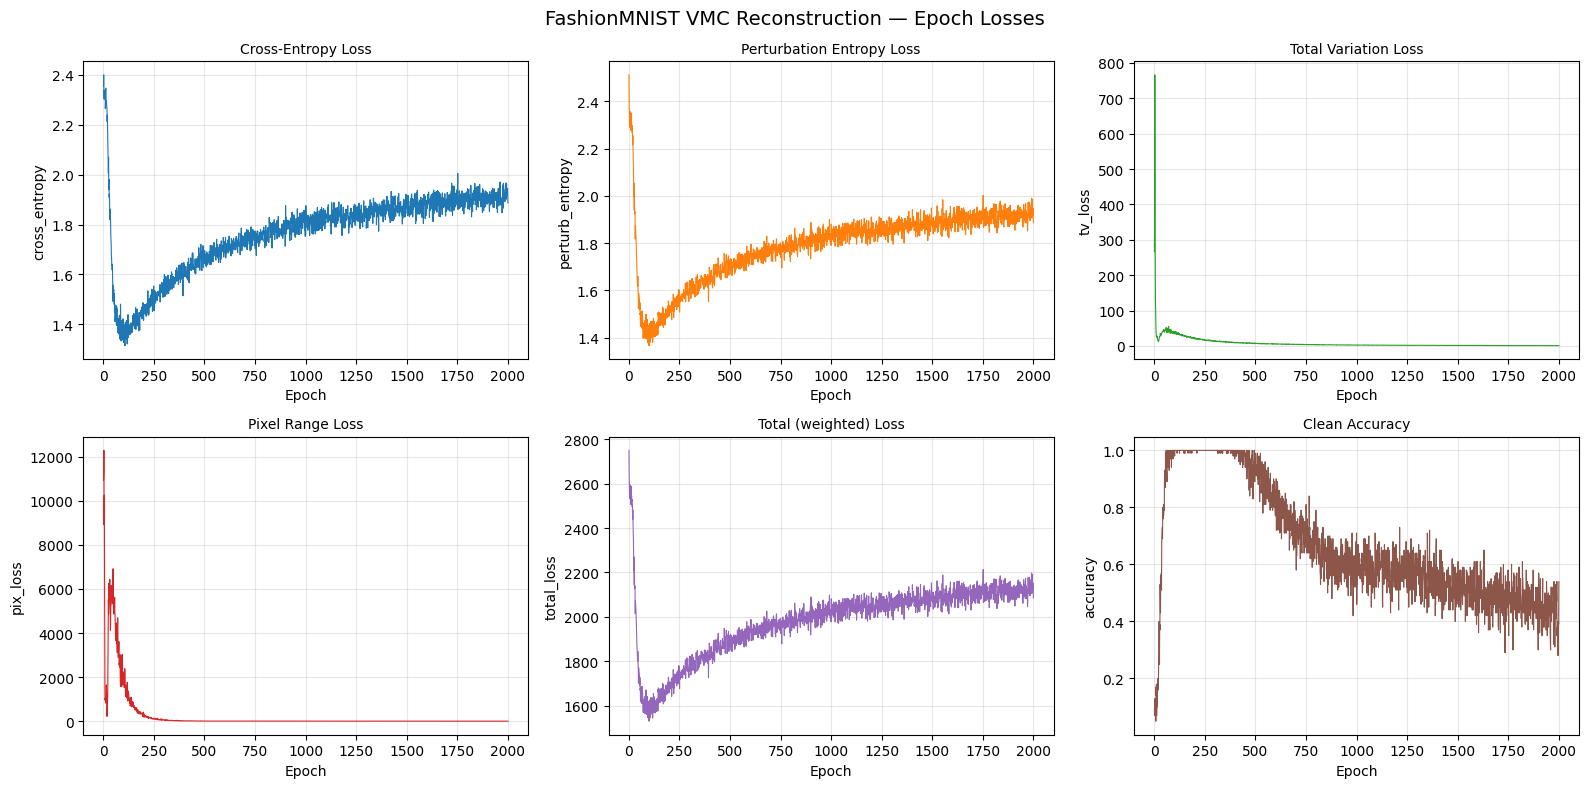

Plot saved to: FashionMNIST-Reconstruction/loss_curves.png


In [30]:
# ── Plot epoch losses from CSV ────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('FashionMNIST-Reconstruction/epoch_losses.csv')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('FashionMNIST VMC Reconstruction — Epoch Losses', fontsize=14)

metrics = [
    ('cross_entropy',        'Cross-Entropy Loss',         'tab:blue'),
    ('perturb_entropy',      'Perturbation Entropy Loss',  'tab:orange'),
    ('tv_loss',              'Total Variation Loss',        'tab:green'),
    ('pix_loss',             'Pixel Range Loss',            'tab:red'),
    ('total_loss',           'Total (weighted) Loss',       'tab:purple'),
    ('accuracy',             'Clean Accuracy',              'tab:brown'),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    ax.plot(df['epoch'], df[col], color=color, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FashionMNIST-Reconstruction/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to: FashionMNIST-Reconstruction/loss_curves.png")


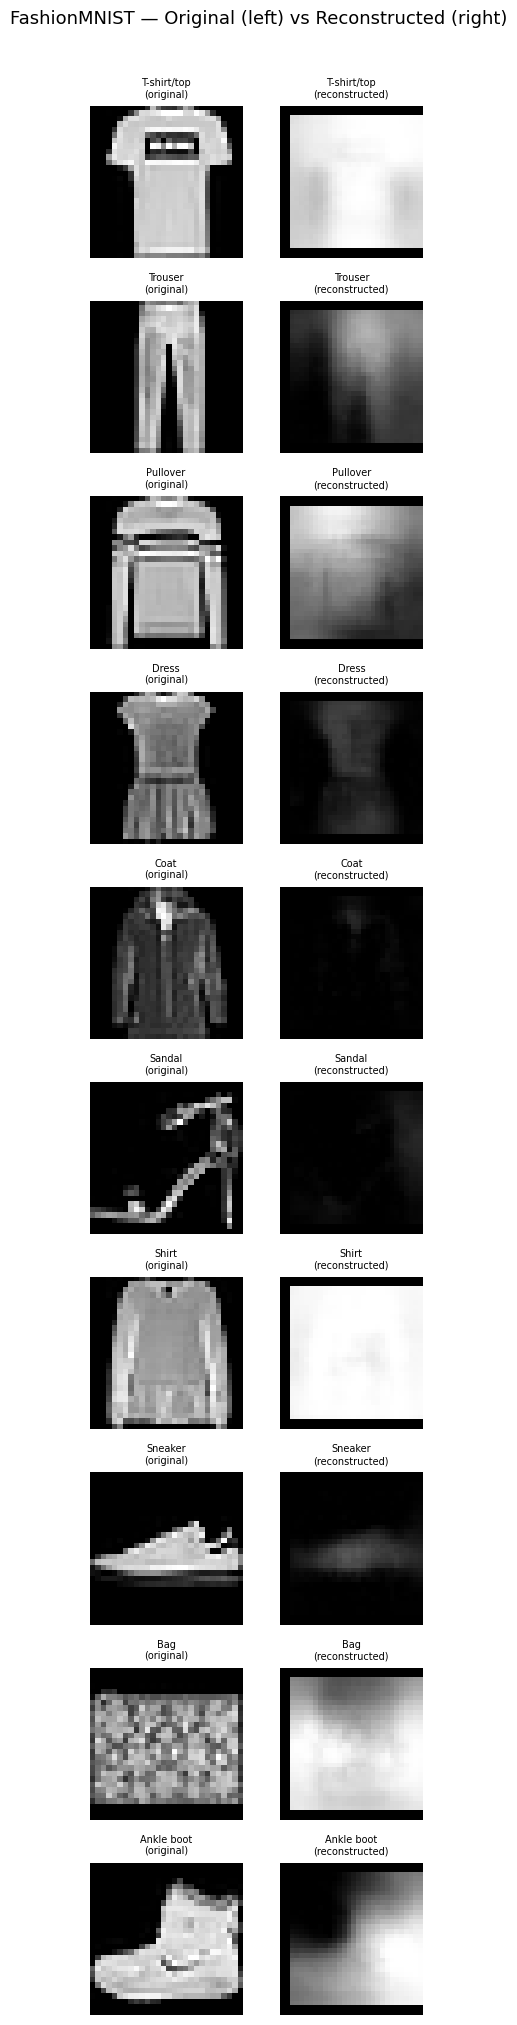

Comparison figure saved to: FashionMNIST-Reconstruction/comparison_orig_vs_recon.png


In [31]:
# ── Side-by-side: original training sample vs best reconstructed image ─────────
from PIL import Image
import glob, os
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch.nn.functional as F

# Collect the original training images (1 per class, ordered 0-9)
orig_images = {}
for img, label in train_dataset:
    lbl = label if isinstance(label, int) else label.item()
    if lbl not in orig_images:
        orig_images[lbl] = img  # (1, 28, 28) tensor
    if len(orig_images) == N_CLASSES:
        break

# Load the LAST saved reconstructed image grid and extract per-class patches
last_img_path = sorted(glob.glob('FashionMNIST-Reconstruction/image_*.png'))[-1]
grid_img = Image.open(last_img_path)
grid_arr = np.array(grid_img)          # shape: (H, W) or (H, W, 3)

# The grid was saved with nrow=10 so each column = one class
grid_h, grid_w = grid_arr.shape[:2]
cell_w = grid_w // N_CLASSES           # width of each cell in the grid
cell_h = grid_h                        # only 1 row

# ── Plot: 2 columns per class (Original | Reconstructed) ─────────────────────
fig, axes = plt.subplots(N_CLASSES, 2, figsize=(4, N_CLASSES * 2))
fig.suptitle('FashionMNIST — Original (left) vs Reconstructed (right)', fontsize=13, y=1.01)

# Un-normalise helper (approximate visual only)
inv_mean = -fashion_mean / fashion_std
inv_std  =  1.0 / fashion_std

for cls in range(N_CLASSES):
    # ── Original ──────────────────────────────────────────────────────────────
    orig_t = orig_images[cls].squeeze()      # (28, 28)
    orig_np = (orig_t.numpy() * fashion_std + fashion_mean)
    orig_np = np.clip(orig_np, 0, 1)

    axes[cls][0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
    axes[cls][0].set_title(f"{CLASS_NAMES[cls]}\n(original)", fontsize=7)
    axes[cls][0].axis('off')

    # ── Reconstructed (slice from saved grid) ─────────────────────────────────
    x0 = cls * cell_w
    x1 = x0 + cell_w
    patch = grid_arr[:cell_h, x0:x1]

    axes[cls][1].imshow(patch, cmap='gray')
    axes[cls][1].set_title(f"{CLASS_NAMES[cls]}\n(reconstructed)", fontsize=7)
    axes[cls][1].axis('off')

plt.tight_layout()
plt.savefig('FashionMNIST-Reconstruction/comparison_orig_vs_recon.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison figure saved to: FashionMNIST-Reconstruction/comparison_orig_vs_recon.png")
